In [1]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

import matplotlib.pyplot as plt

import tqdm

import numpy as np
from config import Config

from network import NetCNN1D, NetCNN2D

import os, sys

from sklearn.model_selection import StratifiedKFold
import tqdm

import numpy as np
import sys, os

import matplotlib.pyplot as plt

import dataset_BCICIV2a
from config_BCICIV2a import Config


import pywt, cv2


from akida_models import fetch_file, akidanet_imagenet



config = Config()




# Choose from: 'Left', 'Right', 'Foot' and 'Tongue'
config.used_classes = ['Left', 'Right']

# select from 1 to 22 below
config.used_channels = [   
                            8,10,12
                     ]


config.t_start = -0.1
config.t_end = 3.0

In [2]:
# Create a base model without top layers
base_model = akidanet_imagenet(input_shape=(224, 224, 3),
                               classes=2,
                               alpha=0.5,
                               include_top=False,
                               pooling='avg')

# Get pretrained quantized weights and load them into the base model
pretrained_weights = fetch_file(
    origin="https://data.brainchip.com/models/AkidaV2/akidanet/akidanet_imagenet_224_alpha_0.5.h5",
    fname="akidanet_imagenet_224_alpha_0.5.h5",
    cache_subdir='models')

base_model.load_weights(pretrained_weights, by_name=True)


from keras import Model
from keras.layers import Activation, Dropout, Reshape
from akida_models.layer_blocks import dense_block

x = base_model.output
x = dense_block(x,
                units=512,
                name='fc1',
                add_batchnorm=True,
                relu_activation='ReLU7.5')
x = Dropout(0.25, name='dropout_1')(x)
x = dense_block(x,
                units=2,
                name='predictions',
                add_batchnorm=False,
                relu_activation=False)
#x = Activation('softmax', name='act_softmax')(x)
#x = Reshape((2,), name='reshape')(x)

# Build the model
model_keras = Model(base_model.input, x, name='akidanet')



for layer in model_keras.layers:
    # Freeze all layers by default
    layer.trainable = False

    # Unfreeze 'fc1' and 'predictions' layers
    if layer.name == 'fc1' or layer.name == 'predictions' or layer.name == 'pw_separable_13' or layer.name == 'dw_separable_13':
        layer.trainable = True


model_keras.summary()



Model: "akidanet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 224, 224, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv_0 (Conv2D)             (None, 112, 112, 16)      432       
                                                                 
 conv_0/BN (BatchNormalizat  (None, 112, 112, 16)      64        
 ion)                                                            
                                                                 
 conv_0/relu (ReLU)          (None, 112, 112, 16)      0         
                                                                 
 conv_1 (Conv2D)             (None, 112, 112, 32)      4608      
                                                         

In [3]:
def get_CWT(x):
    # x shape: (N, Channels, Time)

    time = np.linspace(0, 1, x.shape[2])
    widths = np.geomspace(1, 700, num=225)
    wavelet = "cmor1.5-1.0"
    sampling_period = np.diff(time).mean()
            
    cwtmatr, freqs = pywt.cwt(x, widths, wavelet, sampling_period=sampling_period)
    cwtmatr = np.abs(cwtmatr[:-1,:, :, :-1])
    

    x_cwt_resized = []
    for n in range(x.shape[0]):
        x_channels = []
        for ch in range(x.shape[1]):
            x_channels.append(cv2.resize(cwtmatr[:, n, ch], (224,224), interpolation=cv2.INTER_CUBIC))

        x_cwt_resized.append(np.array(x_channels))

    x_cwt_resized = np.array(x_cwt_resized)
    x_cwt_resized = (x_cwt_resized - np.mean(x_cwt_resized)) / np.std(x_cwt_resized)

    return x_cwt_resized

In [5]:
subject_accs = []
subjects_std = []
for subject_id in tqdm.tqdm(range(9, 10)):
    if subject_id == 4:
        continue
    
    X, y = dataset_BCICIV2a.subject_dataset(config, subject_id)
    crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    acc = []
    
    for train_index, valid_index in crossValidation_KF.split(X, y):
        # Reset model for each fold
        #model_keras = create_model()  # You need to define this function
        
        X_train = X[train_index]
        Y_train = y[train_index]
        X_valid = X[valid_index]
        Y_valid = y[valid_index]

        # Preprocess data once
        X_train_cwt = get_CWT(X_train)
        X_train_cwt = X_train_cwt.transpose(0, 3, 2, 1)
        X_valid_cwt = get_CWT(X_valid)
        X_valid_cwt = X_valid_cwt.transpose(0, 3, 2, 1)

        Y_train = tf.keras.utils.to_categorical(Y_train, num_classes=2)
        Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes=2)
        
        batch_size = 32
        train_dataset = tf.data.Dataset.from_tensor_slices((X_train_cwt, Y_train))
        train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)

        model_keras.compile(
            loss=CategoricalCrossentropy(from_logits=True, label_smoothing=0.0),
            optimizer=keras.optimizers.Adam(learning_rate=2e-4, weight_decay=1e-6), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
        ) 

        # Use built-in training method
        history = model_keras.fit(
            train_dataset,
            validation_data=(X_valid_cwt, Y_valid),
            epochs=100,
            verbose=1
        )
        
        # Get final validation accuracy
        _, val_acc = model_keras.evaluate(X_valid_cwt, Y_valid, verbose=0)
        acc.append(val_acc)

    subject_accs.append(np.mean(acc))
    subjects_std.append(np.std(acc))

print("\n\n ====================================")
for i in range(len(subject_accs)):
    subject_id = i+1
    if i >= 3:
        subject_id += 1 
    print(f"subject {subject_id} = {100*subject_accs[i]:.2f}% +- {100*subjects_std[i]:.1f}")

  0%|          | 0/1 [00:00<?, ?it/s]

Extracting EDF parameters from c:\Users\Hammo\OneDrive\Desktop\Neurobus\BCICIV_2a_gdf\A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-0.1, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 72 events and 776 original time points ...


C:\Users\Hammo\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


0 bad epochs dropped
Loading data for 72 events and 776 original time points ...
0 bad epochs dropped
Epoch 1/100

4/4 [==============================] - 6s 545ms/step - loss: 0.9116 - acc: 0.4783 - val_loss: 0.8960 - val_acc: 0.4828
Epoch 2/100
4/4 [==============================] - 1s 239ms/step - loss: 0.9114 - acc: 0.4609 - val_loss: 0.8352 - val_acc: 0.5517
Epoch 3/100
4/4 [==============================] - 1s 234ms/step - loss: 0.8746 - acc: 0.5043 - val_loss: 0.8313 - val_acc: 0.4828
Epoch 4/100
4/4 [==============================] - 1s 218ms/step - loss: 0.8761 - acc: 0.4522 - val_loss: 0.8308 - val_acc: 0.5517
Epoch 5/100
4/4 [==============================] - 1s 219ms/step - loss: 0.8295 - acc: 0.5565 - val_loss: 0.8287 - val_acc: 0.6552
Epoch 6/100
4/4 [==============================] - 1s 245ms/step - loss: 0.8808 - acc: 0.4435 - val_loss: 0.8263 - val_acc: 0.5172
Epoch 7/100
4/4 [==============================] - 1s 220ms/step - loss: 0.8360 - acc: 0.5130 - val_loss: 0.825

  0%|          | 0/1 [05:02<?, ?it/s]


KeyboardInterrupt: 

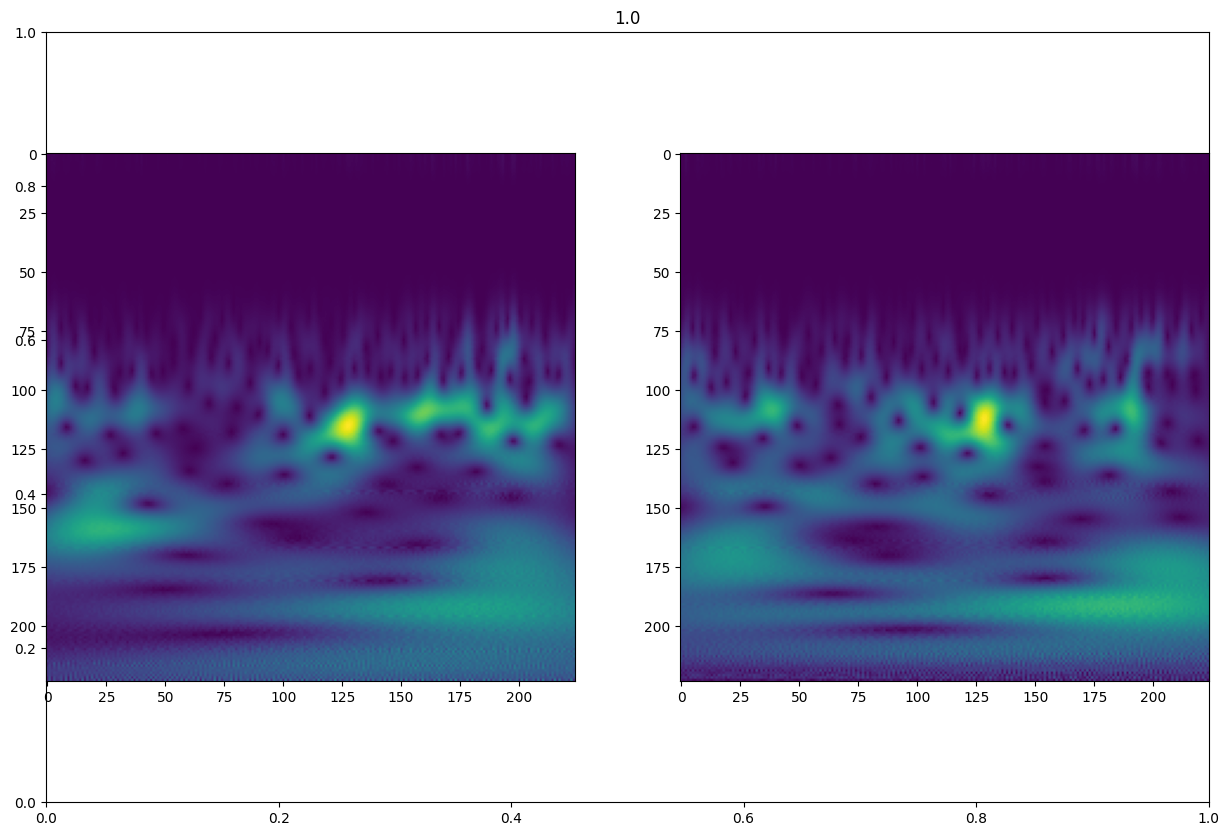

In [ ]:
plt.figure(figsize = (15, 10))
plt.title(Y_valid[0])
plt.subplot(1,2,1)
plt.imshow(X_valid_cwt[0,0])
plt.subplot(1,2,2)
plt.imshow(X_valid_cwt[0,2])